# 

# Visualize Cell Dynamics  
专注于“可视化”

In [ ]:
import scdiffeq as sdq

### Load a Simulation

**Note**: see the Quickstart notebook for how to generate simulated data from a model.  
这个模拟数据这么重要的吗

指向本地存储的模型路径 (project_path)，初始化 sdq.io.Project

In [2]:
h5ad_path = "/content/drive/MyDrive/adata_sim.larry.h5ad"

adata_sim = sdq.io.read_h5ad(h5ad_path)

AnnData object with n_obs × n_vars = 62976 × 50
    obs: 't', 'z0_idx', 'sim_i', 'sim', 'Cell type annotation', 'fate'
    uns: 'fate_counts', 'gene_ids', 'sim_idx', 'simulated', 'h5ad_path'
    obsm: 'X_gene', 'X_gene_inv', 'X_umap'


### Plot fate-conditional temporal expression

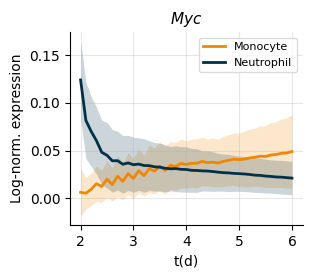

In [3]:
axes = sdq.pl.temporal_expression(
    adata_sim=adata_sim,
    groupby="fate",
    gene="Myc",
    use_key="X_gene_inv",
    cmap = {
        "Monocyte": "#F08700",
        "Neutrophil": "#023047",
    },
    groups = ["Monocyte", "Neutrophil"]
)

### UMAP of a simulation

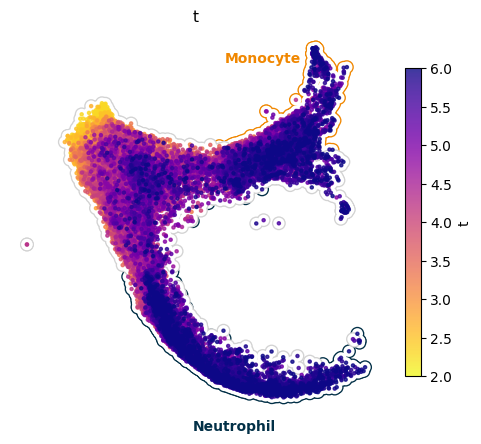

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

from typing import Optional

cmap = {
    "Undifferentiated":"lightgrey",
    "Monocyte": "#F08700",
    "Neutrophil": "#023047",
}

def plot_background(adata_sim, ax, idx: Optional[pd.Index] = None, c: Optional[str] = "k"):

  if idx is None:
    xu = adata_sim.obsm["X_umap"]
  else:
    xu = adata_sim[idx].obsm["X_umap"]
  ax.scatter(xu[:, 0], xu[:, 1], c=c, ec = "None", rasterized=True, s = 100)
  ax.scatter(xu[:, 0], xu[:, 1], c="w", ec = "None", rasterized=True, s = 65)

state_grouped = adata_sim.obs.groupby("Cell type annotation")

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

for group, group_df in state_grouped:
  plot_background(adata_sim, ax=ax, idx=group_df.index, c = cmap[group])

sdq.pl.simulation_umap(
    adata_sim=adata_sim,
    ax=ax,
    cmap="plasma_r",
    zorder=5,
    s=5,
    show_colorbar=True,
)

t1 = ax.text(10.5, 10, "Monocyte", fontsize=10, ha='center', va='center', color="#F08700", weight='bold')
t2 = ax.text(9.5, -3.5, "Neutrophil", fontsize=10, ha='center', va='center', color="#023047", weight='bold')

### UMAP trajectory GIF  
在UMAP基础上面打上轨迹

In [11]:
sdq.pl.simulation_trajectory_gif(
    adata_sim,
    background_groupby="Cell type annotation",
    background_cmap=cmap,
    savename="trajectory.gif"
)

'trajectory.gif'

### Dual-panel UMAP / fate-conditional temporal expression

In [7]:
umap_labels = [
    {"text": "Monocyte", "x": 10.5, "y": 10, "color": "#F08700", "fontsize": 10, "weight": "bold"},
    {"text": "Neutrophil", "x": 9.5, "y": -3.5, "color": "#023047", "fontsize": 10, "weight": "bold"},
]

GENE = "Spi1"

sdq.pl.simulation_expression_gif(
    adata_sim,
    gene=GENE,
    groupby="fate",
    groups=["Monocyte", "Neutrophil"],
    background_groupby="Cell type annotation",
    background_cmap=cmap,
    expr_cmap=cmap,
    savename=f"simulated_expression.{GENE}.gif",
    umap_labels=umap_labels,
    expr_width_scale=0.8,
    expr_height_scale=0.8,
)


'simulated_expression.Spi1.gif'

结果展示工具  应该是3个文件中的最后一环